# Part 2: Random Search NAS

## 이 노트북에서 다루는 내용
1. Random Search 전략의 원리
2. 탐색 공간에서 무작위 아키텍처 샘플링 및 평가
3. 최적 아키텍처 선정 및 전체 학습
4. Baseline과 비교 분석

## Random Search 핵심 개념

**Random Search**: 탐색 공간에서 N개의 아키텍처를 무작위로 샘플링하여 가장 좋은 것을 선택

### 과정
1. 탐색 공간에서 N개 아키텍처를 무작위 샘플링
2. 각 아키텍처를 축소 학습(5 epochs)으로 빠르게 평가
3. 가장 성능이 좋은 아키텍처를 최종 선택
4. 선택된 아키텍처를 전체 학습(10 epochs)

### 장점
- 구현이 매우 간단 (baseline 탐색 전략)
- 병렬화 용이 (각 아키텍처 독립 평가)
- 놀라울 정도로 경쟁력 있는 성능 (Li & Talwalkar, 2020)

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN, FlexibleCNN, SEARCH_SPACE,
    sample_architecture, architecture_to_string
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# NAS 전용
SEARCH_EPOCHS = 5
FULL_EPOCHS = 10
NUM_SAMPLES = 20

SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습 및 평가 함수 정의

In [3]:
def train(model, train_loader, epochs, learning_rate, device, verbose=True):
    """Cross-Entropy 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        if verbose:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def test(model, test_loader, device):
    """모델 평가"""
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def train_and_evaluate(arch, train_loader, test_loader, epochs, learning_rate, device, seed=42):
    """하나의 아키텍처를 학습하고 평가"""
    torch.manual_seed(seed)
    model = FlexibleCNN(arch, num_classes=NUM_CLASSES)
    params = count_parameters(model)

    start_time = time.time()
    train_losses = train(model, train_loader, epochs, learning_rate, device, verbose=False)
    train_time = time.time() - start_time

    accuracy = test(model, test_loader, device)

    return {
        'arch': arch, 'accuracy': accuracy, 'params': params,
        'train_losses': train_losses, 'train_time': train_time
    }

## [3] Baseline 준비

In [4]:
torch.manual_seed(SEED)
baseline_model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
baseline_params = count_parameters(baseline_model)
print(f"Baseline 파라미터: {baseline_params:,}")

print("\nBaseline 학습 중...")
train(baseline_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(baseline_model, test_loader, DEVICE)
print(f"Baseline 정확도: {baseline_accuracy:.2f}%")

Baseline 파라미터: 1,186,986

Baseline 학습 중...
Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
Baseline 정확도: 75.01%


## [4] Random Search 실행

20개의 아키텍처를 무작위 샘플링하여 축소 학습(5 epochs)으로 평가합니다.

In [5]:
search_results = []

print(f"Random Search: {NUM_SAMPLES}개 아키텍처 탐색")
print(f"축소 학습: {SEARCH_EPOCHS} epochs per architecture")
print("-" * 60)

total_start = time.time()

for i in range(NUM_SAMPLES):
    arch = sample_architecture(seed=SEED + i)
    arch_str = architecture_to_string(arch)

    result = train_and_evaluate(
        arch, train_loader, test_loader,
        SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
    )
    search_results.append(result)

    print(f"  [{i+1}/{NUM_SAMPLES}] {arch_str} | "
          f"Acc: {result['accuracy']:.2f}% | "
          f"Params: {result['params']:,} | "
          f"Time: {result['train_time']:.1f}s")

search_time = time.time() - total_start

# 정확도 기준 정렬
search_results.sort(key=lambda x: x['accuracy'], reverse=True)

print("-" * 60)
print(f"총 탐색 시간: {search_time:.1f}s")
print(f"Best: {architecture_to_string(search_results[0]['arch'])} | "
      f"Acc: {search_results[0]['accuracy']:.2f}%")

Random Search: 20개 아키텍처 탐색
축소 학습: 5 epochs per architecture
------------------------------------------------------------
  [1/20] F[16-16-64-32]_K[3-3-3-3]_FC1024 | Acc: 73.16% | Params: 566,074 | Time: 42.3s
  [2/20] F[16-64-32-128]_K[5-3-5-5]_FC128 | Acc: 74.67% | Params: 427,818 | Time: 47.1s
  [3/20] F[128-16-32-128]_K[3-5-3-3]_FC128 | Acc: 73.06% | Params: 359,994 | Time: 44.6s
  [4/20] F[64-128-128-64]_K[3-5-5-3]_FC128 | Acc: 75.18% | Params: 822,730 | Time: 54.5s
  [5/20] F[16-128-16-32]_K[3-3-3-3]_FC512 | Acc: 72.66% | Params: 309,882 | Time: 47.5s
  [6/20] F[64-16-128-128]_K[5-5-5-5]_FC128 | Acc: 74.76% | Params: 755,098 | Time: 48.1s
  [7/20] F[64-32-64-32]_K[5-3-3-3]_FC1024 | Acc: 75.61% | Params: 595,850 | Time: 48.3s
  [8/20] F[16-64-128-16]_K[5-3-3-5]_FC256 | Acc: 73.68% | Params: 203,930 | Time: 47.5s
  [9/20] F[128-64-64-32]_K[5-5-3-5]_FC256 | Acc: 75.14% | Params: 436,650 | Time: 52.4s
  [10/20] F[32-32-32-32]_K[5-5-5-5]_FC512 | Acc: 74.07% | Params: 347,114 | Time: 46

## [5] Best 아키텍처 전체 학습

In [6]:
best_arch = search_results[0]['arch']
print(f"Best 아키텍처: {architecture_to_string(best_arch)}")
print(f"축소 학습 정확도: {search_results[0]['accuracy']:.2f}%")
print(f"파라미터 수: {search_results[0]['params']:,}")

print(f"\n전체 학습 ({FULL_EPOCHS} epochs):")
torch.manual_seed(SEED)
best_model = FlexibleCNN(best_arch, num_classes=NUM_CLASSES)
train(best_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE)
best_full_accuracy = test(best_model, test_loader, DEVICE)
print(f"전체 학습 정확도: {best_full_accuracy:.2f}%")

Best 아키텍처: F[32-128-64-128]_K[5-5-3-5]_FC512
축소 학습 정확도: 78.24%
파라미터 수: 1,437,898

전체 학습 (10 epochs):
Epoch 1/10, Loss: 1.4378
Epoch 2/10, Loss: 0.9244
Epoch 3/10, Loss: 0.7294
Epoch 4/10, Loss: 0.6028
Epoch 5/10, Loss: 0.5083
Epoch 6/10, Loss: 0.4164
Epoch 7/10, Loss: 0.3324
Epoch 8/10, Loss: 0.2715
Epoch 9/10, Loss: 0.2141
Epoch 10/10, Loss: 0.1812
전체 학습 정확도: 77.48%


## [6] 결과 시각화

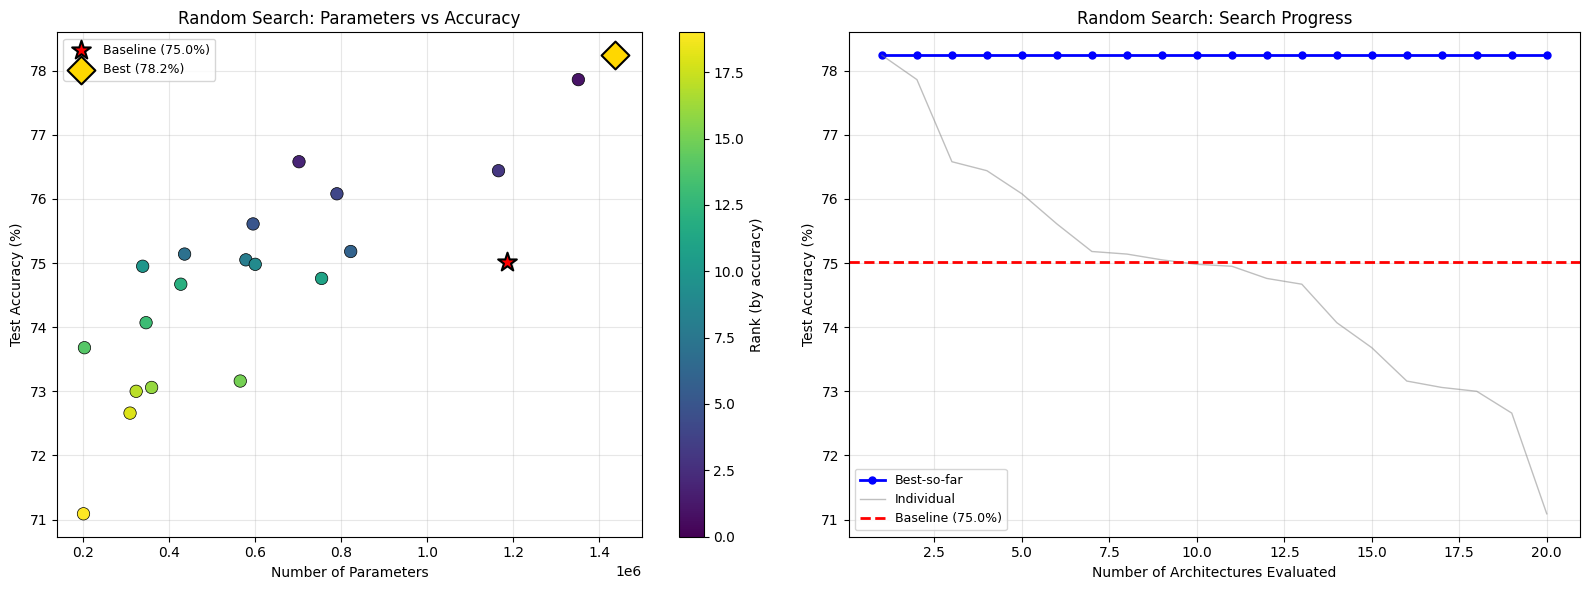

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 파라미터 수 vs 정확도 ---
ax1 = axes[0]
accs = [r['accuracy'] for r in search_results]
params = [r['params'] for r in search_results]

scatter = ax1.scatter(params, accs, c=range(len(search_results)),
                      cmap='viridis', s=80, edgecolors='black', linewidth=0.5, zorder=3)
plt.colorbar(scatter, ax=ax1, label='Rank (by accuracy)')

ax1.scatter([baseline_params], [baseline_accuracy], c='red', s=200,
            marker='*', edgecolors='black', linewidth=1.5,
            zorder=4, label=f'Baseline ({baseline_accuracy:.1f}%)')

best = search_results[0]
ax1.scatter([best['params']], [best['accuracy']], c='gold', s=200,
            marker='D', edgecolors='black', linewidth=1.5,
            zorder=4, label=f'Best ({best["accuracy"]:.1f}%)')

ax1.set_xlabel('Number of Parameters')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Random Search: Parameters vs Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: 탐색 진행 곡선 ---
ax2 = axes[1]

# 원래 순서에서 best-so-far 계산 (정렬 전 순서로 복원)
original_order_accs = [r['accuracy'] for r in sorted(search_results, key=lambda x: search_results.index(x))]
best_so_far = []
current_best = 0
for acc in original_order_accs:
    current_best = max(current_best, acc)
    best_so_far.append(current_best)

ax2.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o',
         markersize=5, linewidth=2, label='Best-so-far')
ax2.plot(range(1, len(original_order_accs) + 1), original_order_accs, 'gray',
         alpha=0.5, linewidth=1, label='Individual')
ax2.axhline(y=baseline_accuracy, color='red', linestyle='--',
            linewidth=2, label=f'Baseline ({baseline_accuracy:.1f}%)')

ax2.set_xlabel('Number of Architectures Evaluated')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Random Search: Search Progress')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 결과 요약

In [8]:
print("=" * 60)
print("결과 요약: Random Search vs Baseline")
print("=" * 60)
print(f"{'Method':<25} {'Accuracy':<15} {'Parameters':<15}")
print("-" * 55)
print(f"{'Baseline (Human)':<25} {baseline_accuracy:>10.2f}% {baseline_params:>12,}")
print(f"{'Random Search (축소)':<25} {search_results[0]['accuracy']:>10.2f}% {search_results[0]['params']:>12,}")
print(f"{'Random Search (전체)':<25} {best_full_accuracy:>10.2f}% {search_results[0]['params']:>12,}")
print("-" * 55)

acc_diff = best_full_accuracy - baseline_accuracy
param_ratio = search_results[0]['params'] / baseline_params * 100
print(f"\n정확도 차이: {acc_diff:+.2f}%")
print(f"파라미터 비율: {param_ratio:.1f}% (Baseline 대비)")
print(f"탐색 비용: {NUM_SAMPLES}개 x {SEARCH_EPOCHS} epochs = 총 {search_time:.1f}s")

결과 요약: Random Search vs Baseline
Method                    Accuracy        Parameters     
-------------------------------------------------------
Baseline (Human)               75.01%    1,186,986
Random Search (축소)             78.24%    1,437,898
Random Search (전체)             77.48%    1,437,898
-------------------------------------------------------

정확도 차이: +2.47%
파라미터 비율: 121.1% (Baseline 대비)
탐색 비용: 20개 x 5 epochs = 총 991.7s
